# **Introduction**

### **CMS Experiment**

The CMS (Compact Muon Solenoid) experiment is one of the main detectors at the Large Hadron Collider (LHC) at CERN, located near Geneva, Switzerland. It is a general purpose detector designed to study high energy proton–proton collisions, enabling a wide range of physics measurements, including studies of the Higgs boson, Standard Model processes, and searches for new physics. CMS is built around a large superconducting solenoid magnet and consists of several main components: 
* an inner tracking system to measure particle trajectories and determine their electric charge from their curvature in the magnetic field
* electromagnetic calorimeters (ECAL) to measure the energies of electrons and photons
* hadronic calorimeters (HCAL) to measure the energies of hadrons such as neutrons and pions
* muon chambers surrounding the magnet to identify muons 

While CMS is capable of reconstructing individual particles using information from its various subdetectors, many physics processes at the LHC involve quarks and gluons, which cannot be observed directly. Instead, their presence must be inferred from the patterns of particles they produce in the detector. One of the most important such composite objects used for this purpose is the jet. 

A jet is a collimated spray of particles produced when a parton (quark or a gluon) is created in a high-energy collision. Because quarks and gluons cannot exist freely (a property called color confinement), they transform into many observable particles (mainly hadrons) that travel in roughly the same direction. This group of particles is what we call a jet. In the CMS experiment, jets are reconstructed as well-defined objects by applying a clustering algorithm to the particles measured in the tracker and calorimeters.

![](https://i.imgur.com/MO5IHaH.png)

### **Columnar analysis**

The traditional way of analyzing data in HEP involves an event loop. In this paradigm, we would write an explicit loop to go through every event (and through every field of an event that we wish to make a cut on). This method of analysis is rather bulky in comparison to the columnar approach, which (ideally) has no explicit loops at all! Instead, the fields of our data are treated as arrays and analysis is done by way of numpy-like array operations.

![](https://i.imgur.com/LKcMTG0.png)

We will study basic tools and wrappers for enabling not-too-alien syntax when running columnar collider HEP analysis. This tools are part of a pythonic HEP ecosystem. 

![](https://i.imgur.com/3a11SeT.png)

To make things easier to find, they're cataloged under a common name at [scikit-hep.org](https://scikit-hep.org/)

# **Reading and manipulating data**

A ROOT file is like a little filesystem containing nested directories. Any class instance can be stored in a directory. One of these classes, TTree, is a gateway to large datasets. A TTree is roughly like a Pandas DataFrame in that it represents a table of data. The columns are called TBranches, which can be nested (unlike Pandas). The rows usually represent events (individual bunch crossings).

![](https://i.imgur.com/gkN0q9f.png)

[Uproot](https://uproot.readthedocs.io/en/latest/) is a Python package that reads and writes ROOT files and is only concerned with reading and writing (no analysis, no plotting, etc.).

We can use `uproot.open()` to open a ROOT file:

In [ ]:
!pip install coffea numpy awkward uproot matplotlib mplhep correctionlib

In [1]:
import uproot

# The key `events` refers to a TTree object. This is where all the data in this file is stored. 
events = uproot.open("https://scikit-hep.org/uproot3/examples/Zmumu.root:events")

events.keys()

['Type',
 'Run',
 'Event',
 'E1',
 'px1',
 'py1',
 'pz1',
 'pt1',
 'eta1',
 'phi1',
 'Q1',
 'E2',
 'px2',
 'py2',
 'pz2',
 'pt2',
 'eta2',
 'phi2',
 'Q2',
 'M']

To get the actual data from the table we can use the `arrays()` function. Let's select some muons' kinematic variables 
* Transverse momentum $p_T$
* pseudorapidity ($\eta=-\ln \left[\tan \left(\frac{\theta}{2}\right)\right]$)
* $\phi$ angle



In [2]:
muons = events.arrays(["pt1", "eta1", "phi1", "pt2", "eta2", "phi2"])
muons

<Array [{pt1: 44.7, eta1: -1.22, ...}, ...] type='2304 * {pt1: float64, eta...'>

This is an Awkward array. [Awkward](https://awkward-array.org/doc/main/index.html) is a library, part of the Pythonic HEP ecosystem, designed to manipulate regular and **irregular** arrays using NumPy-like idioms. In this sense, it can be seen as a generalization of NumPy to support irregular data.

**operations:** Arrays are dynamically typed, but operations on them are compiled and fast. Let's compute the dimuon invariant mass $m(\mu_1, \mu_2)$ using the following formula: $$m^2(\mu_1, \mu_2) = 2 p_T(\mu_1)p_T(\mu_2)f(\eta, \phi)$$

where $$f(\eta, \phi) = \cosh[\eta(\mu_1) - \eta(\mu_2)] - \cos[\phi(\mu_1) - \phi(\mu_2)]$$

In [3]:
import numpy as np

invariant_mass = np.sqrt(
    2
    * muons.pt1
    * muons.pt2
    * (np.cosh(muons.eta1 - muons.eta2) - np.cos(muons.phi1 - muons.phi2))
)

print(invariant_mass)

[83.6, 83.6, 83.6, 83.6, 89.8, 89.8, 89.8, ..., 60.1, 60.1, 96, 96, 96, 96]


## **Reading data with Coffea NanoEvents**

Awkward arrays let us access data in a columnar fashion, but that's just the first part of doing an analysis. [Coffea](https://coffeateam.github.io/coffea/) builds upon this foundation with a variety of features that better enable us to do our analyses.

NanoEvents is a Coffea utility that allows us to apply a schema to our awkward array. This schema imposes behavior that we would not have in a simple awkward array. On one hand, it can serve to better organize our data by providing a structure for naming, nesting, and cross-referencing fields; on the other, it allows us to add physics object methods (e.g., for LorentzVectors).

We will use NanoEvents to read a small CMS NanoAOD sample. The events object can be instantiated as follows:

In [18]:
import warnings
from coffea.nanoevents import NanoEventsFactory, NanoAODSchema
warnings.filterwarnings("ignore", message="Missing cross-reference index ")

#fname = "root://eospublic.cern.ch//eos/root-eos/benchmark/Run2012B_SingleMu.root"
fname = "Run2012B_SingleMu.root"
events = NanoEventsFactory.from_root(
    file={fname: "Events"},
    schemaclass=NanoAODSchema,
    entry_stop=1000,
    mode="eager",
).events()

/home/juan/Workspace/Base/GFIF/.venv/lib/python3.11/site-packages/coffea/nanoevents/schemas/nanoaod.py:322: RuntimeWarning: Branch Photon_mass already exists but its values will be replaced with 0.0
  warnings.warn(
/home/juan/Workspace/Base/GFIF/.venv/lib/python3.11/site-packages/coffea/nanoevents/schemas/nanoaod.py:322: RuntimeWarning: Branch Photon_charge already exists but its values will be replaced with 0.0
  warnings.warn(


In the constructor, we also pass the desired schema version (the latest version of NanoAOD can be built with `schemaclass=NanoAODSchema`) for this file

In [9]:
events

<NanoEventsArray [<NanoAOD event>, ...] type='100 * event'>

The events object is an array, which at its top level is a record array with one record for each “collection”, where a collection is a grouping of fields (TBranches) based on the naming conventions of NanoAODSchema. 

In [10]:
print(events.fields)

['Jet', 'Muon', 'Tau', 'Photon', 'PV', 'run', 'event', 'luminosityBlock', 'MET', 'HLT', 'Electron']


For example, muon branches are grouped into one sub-record named `Muon`. This illustrates one of the benefits of instantiating a schema: it standardizes how fields are grouped and accessed across datasets.

In [11]:
print(events.Muon.fields)

['pt', 'eta', 'phi', 'mass', 'charge', 'pfRelIso03_all', 'pfRelIso04_all', 'tightId', 'softId', 'dxy', 'dxyErr', 'dz', 'dzErr', 'jetIdx', 'genPartIdx', 'jetIdxG']


In [12]:
events.Muon.pt

<Array [[12.8], [24.8], ..., [31.8], [40.5]] type='100 * var * float32[para...'>

This is an Awkward irregular array, commonly called *jagged* array. A jagged array is an irregular data structure, that is, an array of arrays whose sub-arrays may have different lengths. 

**Indexing and slicing** are a generalization of NumPy's, what NumPy would do if it had variable-length lists:

In [13]:
# muons transverse momentum in the first event
print(events.Muon.pt[0])

[12.8]


In [14]:
# muons transverse momentum in the third event
print(events.Muon.pt[2])

[37.7, 6.99, 3.35, 7.91, 5.38, 9.37]


In [15]:
# leading muon transverse momentum in the third event
events.Muon.pt[2, 0]

np.float32(37.748604)

In [16]:
# leading muon transverse momentum in all events
events.Muon.pt[:, 0]

<Array [12.8, 24.8, 37.7, ..., 31.8, 40.5] type='100 * float32[parameters={...'>

it fails because there are events without muons

In [19]:
import awkward as ak

# see number of events with zero muons
ak.sum(ak.num(events.Muon) == 0)

np.int64(7)

 We can use Awkward's `pad_none()` function to increase the lengths of lists to a target length by adding `None` values.

In [20]:
pad_muons = ak.pad_none(events.Muon, target=2)

# leading muon transverse momentum in all events
print(pad_muons.pt[:, 0])

[12.8, 24.8, 37.7, 30.5, 33.5, 25.3, ..., 33.1, 42.1, 50.7, 8.68, 53.2, 32.7]


In [24]:
pad_muons.pt

<Array [[12.8, None], [...], ..., [32.7, None]] type='1000 * var * ?float32...'>

**Application: selecting objects and events**

**object-level cut**: This jagged array of booleans selects all muons with at least 20 GeV in transverse momentum

In [25]:
muon_pt_cut = events.Muon.pt > 20
muon_pt_cut

<Array [[False], [True], ..., [...], [True]] type='1000 * var * bool[parame...'>

In [26]:
print(events.Muon[muon_pt_cut].pt)

[[], [24.8], [37.7], [30.5], [33.5], ..., [50.7, 22.6], [41.9], [53.2], [32.7]]


**event-level cut**: This non-jagged array of booleans (made with `ak.any`) selects all events that have a muon with at least 20 GeV in transverse momentum:

In [27]:
event_cut  = ak.any(events.Muon.pt > 20, axis=1)
event_cut

<Array [False, True, True, True, ..., True, True, True] type='1000 * bool'>

In [28]:
print(events.Muon[event_cut].pt)

[[24.8], [37.7, 6.99, 3.35, 7.91, 5.38, 9.37], ..., [53.2, 3.69], [32.7]]


#### **Vector behavior**

The first benefit of instantiating a schema is the standardization of fields. In addition, the introduction of collection objects provides a natural place to attach physics-specific methods. Depending on a collection’s name or contents, certain collections can automatically acquire additional methods. For example, although `events.Muon` has the fields:

In [29]:
events.Muon.fields

['pt',
 'eta',
 'phi',
 'mass',
 'charge',
 'pfRelIso03_all',
 'pfRelIso04_all',
 'tightId',
 'softId',
 'dxy',
 'dxyErr',
 'dz',
 'dzErr',
 'jetIdx',
 'genPartIdx',
 'jetIdxG']

we can access additional attributes associated to each generated muon by virtue of the fact that they can be interpreted as Lorentz vectors:

In [30]:
print(events.Muon.energy)

[[15.3], [31.4], [177, 28.5, 12.6, ..., 24.9, 46.3], ..., [177, 16.7], [66.8]]


We can call more complex methods, like computing the distance between two LorentzVector objects
* $\Delta\phi(\text{obj}_1, \text{obj}_2)$

In [31]:
# find distance between leading jet and all muons in each event
print(ak.firsts(events.Jet).delta_phi(events.Muon))

[[-2.9], [2.93], [-2.46, -2.51, ..., -2.43, -2.5], ..., [3.1, -2.96], [-2.77]]


* $\Delta R (\text{obj}_1, \text{obj}_2)= \sqrt{\Delta\phi(\text{obj}_1, \text{obj}_2)^2 - \Delta\eta(\text{obj}_1, \text{obj}_2)^2}$ 

In [32]:
# find distance between leading jet and all muons in each event
print(ak.firsts(events.Jet).delta_r(events.Muon))

[[3.06], [3.34], [2.5, 2.53, 2.19, ..., 2.47, 2.55], ..., [3.32, 3.33], [4]]


We can also use this behavior to compute the dimuon invariant mass:

In [33]:
print((pad_muons[:, 0] + pad_muons[:, 1]).mass)

[None, None, 2.47, None, None, None, ..., None, 97.4, 3.34, 46.3, 5.46, None]


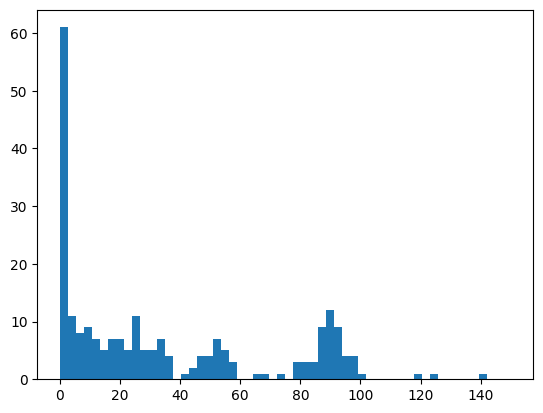

In [40]:
import matplotlib.pyplot as plt
plt.hist((pad_muons[:, 0] + pad_muons[:, 1]).mass, bins="stone", range=(0, 150))
plt.show()

## **Histogramming**

High-energy physicists usually want to fill histograms with more data than can fit in memory, which means setting bin intervals on an empty container and filling it in batches (sequentially or in parallel). Boost-histogram is a library designed for that purpose. 

A more user-friendly layer is provided by a library called [Hist](https://hist.readthedocs.io/en/latest/), which is a powerful histogramming tool within the python HEP ecosystem for analysis based on Boost-histogram. It provides:

* N-dimensional histograms
* Discrete and dense axis: Regular, Boolean, Variable, Integer, IntCategory and StrCategory.
* Useful methods to transform and index histograms
* Plotting via matplotlib or mplhep: stacked and normalized plots, ratio plots, 2D plots, etc.

**1-dimensional Histogram**

In [44]:
import hist

# definition of a regular axis 
muon_pt_axis = hist.axis.Regular(
    bins=50, start=20, stop=150, name="muon_pt", label=r"$p_T(\mu)$ [GeV]"
)

# 1D histogram
muon_pt_histogram = hist.Hist(muon_pt_axis)
muon_pt_histogram

Hist(Regular(50, 20, 150, name='muon_pt', label='$p_T(\\mu)$ [GeV]'), storage=Double())

Since the muon's transverse momentum is a jagged array, it can't be directly histogrammed. Histograms take a set of numbers as inputs, but this array contains lists. We can use `ak.flatten()` to flatten one level of list or `ak.ravel()` to flatten all levels

In [45]:
# filling the histogram
muon_pt_histogram.fill(muon_pt=ak.flatten(events.Muon.pt))
muon_pt_histogram

Hist(Regular(50, 20, 150, name='muon_pt', label='$p_T(\\mu)$ [GeV]'), storage=Double()) # Sum: 934.0 (1328.0 with flow)

we can get a maplotlib plot of the histogram by using the `plot1d()` method

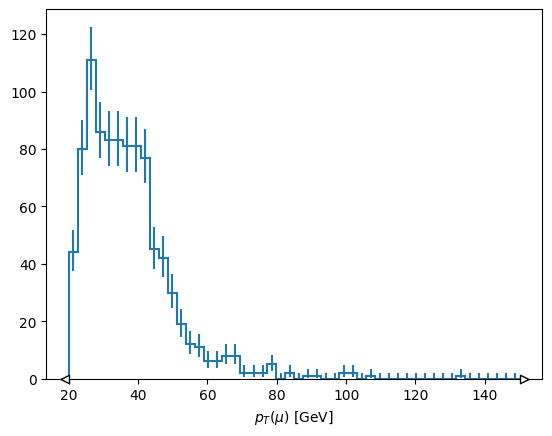

In [46]:
muon_pt_histogram.plot1d();

**N-dimensional Histogram**

In [47]:
# regular axis for eta and phi
muon_eta_axis = hist.axis.Regular(
    bins=50, start=-2.4, stop=2.4, name="muon_eta", label=r"$\eta(\mu)$"
)
muon_phi_axis = hist.axis.Regular(
    bins=50, start=-np.pi, stop=np.pi, name="muon_phi", label=r"$\phi(\mu)$"
)

# 3D histogram
muon_histogram = hist.Hist(
    muon_pt_axis,
    muon_eta_axis,
    muon_phi_axis,
)
muon_histogram

Hist(
  Regular(50, 20, 150, name='muon_pt', label='$p_T(\\mu)$ [GeV]'),
  Regular(50, -2.4, 2.4, name='muon_eta', label='$\\eta(\\mu)$'),
  Regular(50, -3.14159, 3.14159, name='muon_phi', label='$\\phi(\\mu)$'),
  storage=Double())

In [48]:
# filling the histogram
muon_histogram.fill(
    muon_pt=ak.flatten(events.Muon.pt),
    muon_eta=ak.flatten(events.Muon.eta),
    muon_phi=ak.flatten(events.Muon.phi)
)
muon_histogram

Hist(
  Regular(50, 20, 150, name='muon_pt', label='$p_T(\\mu)$ [GeV]'),
  Regular(50, -2.4, 2.4, name='muon_eta', label='$\\eta(\\mu)$'),
  Regular(50, -3.14159, 3.14159, name='muon_phi', label='$\\phi(\\mu)$'),
  storage=Double()) # Sum: 933.0 (1328.0 with flow)

We can inspect an individual axis, using the `project()` method first

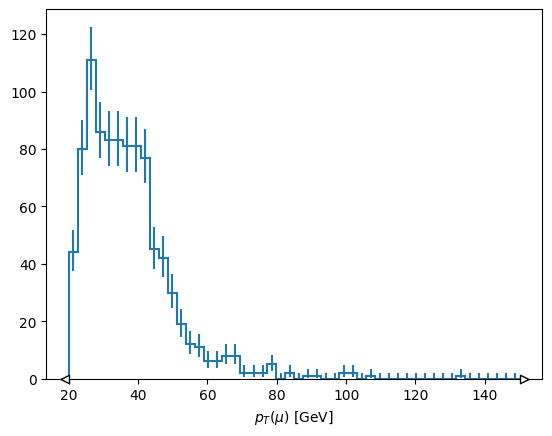

In [49]:
# project into an axis
muon_histogram.project("muon_pt").plot1d();

We could alse visualize 2D histograms using the `plot2d()` method:

In [55]:
# select all entries for the first two axis
muon_histogram.project("muon_pt", "muon_eta", "muon_phi").plot3d()

AttributeError: 'Hist' object has no attribute 'plot3d'

In [52]:
muon_histogram.project("muon_pt", "muon_eta").plot3d()

AttributeError: 'Hist' object has no attribute 'plot3d'

see more about histogram manipulation and transformations [here](https://github.com/CoffeaTeam/coffea/discussions/705)

**Example:** Using 20.000 events:

* Select muons that satisfy the following conditions

  * $p_T \geq 35$ GeV
  * $|\eta| < 2.4$
  * muons with a tight cut-based identification working point (`tightId`)
  * muons with a tight PF Relative Isolation working point (pfRelIso04_all $\leq 0.15$)
* Select events with exactly two muons with opposite charge  
* Compute the dimuon invariant mass $m_{\mu\mu}$ in the range $60 < m_{\mu\mu} < 120$ (GeV)
* Plot a histogram of the dimuon invariant mass

/home/juan/Workspace/Base/GFIF/.venv/lib/python3.11/site-packages/coffea/nanoevents/schemas/nanoaod.py:322: RuntimeWarning: Branch Photon_mass already exists but its values will be replaced with 0.0
  warnings.warn(
/home/juan/Workspace/Base/GFIF/.venv/lib/python3.11/site-packages/coffea/nanoevents/schemas/nanoaod.py:322: RuntimeWarning: Branch Photon_charge already exists but its values will be replaced with 0.0
  warnings.warn(


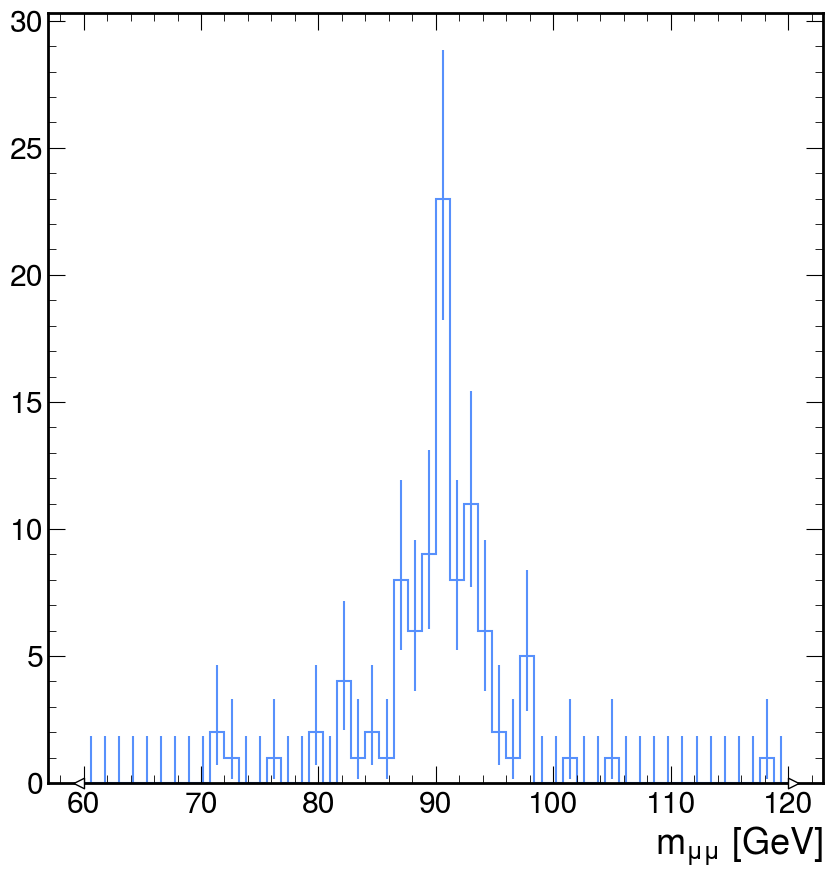

In [62]:
# load NanoEvents
# fname = "root://eospublic.cern.ch//eos/root-eos/benchmark/Run2012B_SingleMu.root"
fname = "Run2012B_SingleMu.root"
events = NanoEventsFactory.from_root(
    file={fname: "Events"},
    schemaclass=NanoAODSchema,
    metadata={"dataset": "Muon"},
    mode="virtual",
).events()

# Select good muons
good_muons = (
    (events.Muon.pt >= 20)
    & (np.abs(events.Muon.eta) < 2.4)
    & events.Muon.tightId
    & (events.Muon.pfRelIso04_all <= 0.15)
)
muons = events.Muon[good_muons]

# select events with exactly two muons with opposite charge
exactly_two_muons = ak.num(muons) == 2
opposite_charge_muons = ak.sum(muons.charge, axis=1) == 0
muons = muons[exactly_two_muons & opposite_charge_muons]

# define dimuon invariant mass
pad_muons = ak.pad_none(muons, target=2)
dimuon_mass = (pad_muons[:, 0] + pad_muons[:, 1]).mass

# select events with dimuon mass in the mass range 60-120 GeV
dimuon_mass_range = (dimuon_mass > 35) & (dimuon_mass < 150)
dimuon_mass = dimuon_mass[dimuon_mass_range]

# Create and plot an histogram of the invariant mass
dimuon_mass_axis = hist.axis.Regular(
    bins=50, start=60, stop=120, name="dimuon_mass", label=r"$m_{\mu\mu}$ [GeV]"
)
dimuon_mass_histogram = hist.Hist(dimuon_mass_axis)
dimuon_mass_histogram.fill(dimuon_mass=dimuon_mass).plot1d();

[mplhep](https://scikit-hep.org/mplhep/) is a Python library built on top of Matplotlib that provides plotting styles and helper functions tailored for high-energy physics (HEP). It makes it easy to produce publication-quality plots following common HEP conventions (such as CMS, ATLAS, or ROOT-like styles), while remaining fully compatible with the standard Matplotlib workflow.

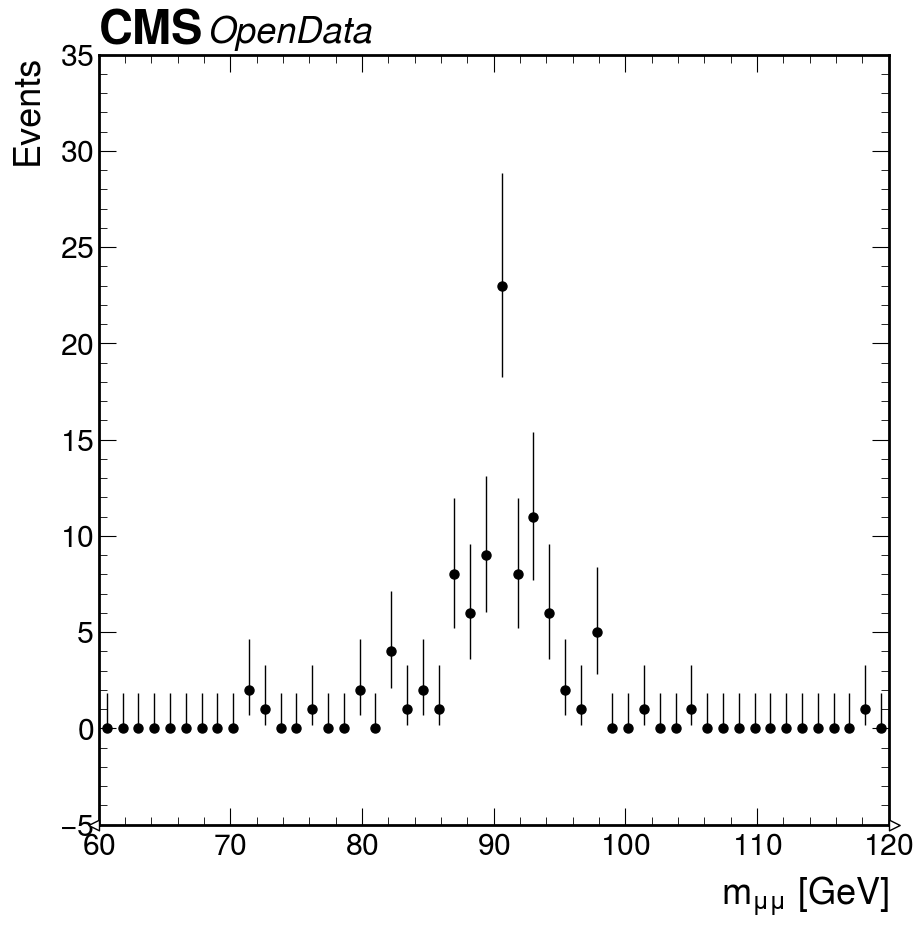

In [71]:
import mplhep as mh
import matplotlib.pyplot as plt

# set a CMS style
mh.style.use(mh.style.CMS)

# plot data histogram
mh.histplot(
    dimuon_mass_histogram,
    histtype="errorbar",
    color="k",
    linestyle="none",
    marker=".",
    markersize=13,
    elinewidth=1,
    yerr=True,
)
mh.cms.text("OpenData")
plt.ylabel("Events");